In [1]:
import pandas as pd

rfm = pd.read_csv('../data/rfm_segmented_labeled.csv', index_col='CustomerID')
rfm.head()


,Recency,Frequency,Monetary,Segment,SegmentLabel
CustomerID,,,,,
12346.0,326,1,77183.60,0,At-Risk VIP
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,0,Lost / Inactive


In [2]:
# 1 = churned, 0 = active
rfm['ChurnFlag'] = (rfm['Recency'] > 180).astype(int)

rfm[['Recency','Frequency','Monetary','SegmentLabel','ChurnFlag']].head()


,Recency,Frequency,Monetary,SegmentLabel,ChurnFlag
CustomerID,,,,,
12346.0,326,1,77183.60,At-Risk VIP,1
12347.0,2,7,4310.00,Regular,0
12348.0,75,4,1797.24,Regular,0
12349.0,19,1,1757.55,Regular,0
12350.0,310,1,334.40,Lost / Inactive,1


In [3]:
churn_summary = (
    rfm
    .groupby('SegmentLabel')['ChurnFlag']
    .agg(['mean','count'])
    .rename(columns={'mean':'ChurnRate','count':'NumCustomers'})
    .round(3)
)

churn_summary


,ChurnRate,NumCustomers
SegmentLabel,,
At-Risk VIP,0.406,515
Lost / Inactive,1.000,574
Loyal High-Value,0.000,346
New Customers,0.000,369
Regular,0.000,2458


In [4]:
rfm_stats = rfm.groupby('SegmentLabel')[['Recency','Frequency','Monetary']].mean().round(2)
segment_insights = rfm_stats.join(churn_summary)
segment_insights


,Recency,Frequency,Monetary,ChurnRate,NumCustomers
SegmentLabel,,,,,
At-Risk VIP,176.47,2.80,1548.16,0.406,515
Lost / Inactive,263.38,1.23,241.03,1.000,574
Loyal High-Value,9.51,20.26,12318.05,0.000,346
New Customers,16.31,1.65,276.88,0.000,369
Regular,49.46,3.52,1458.44,0.000,2458


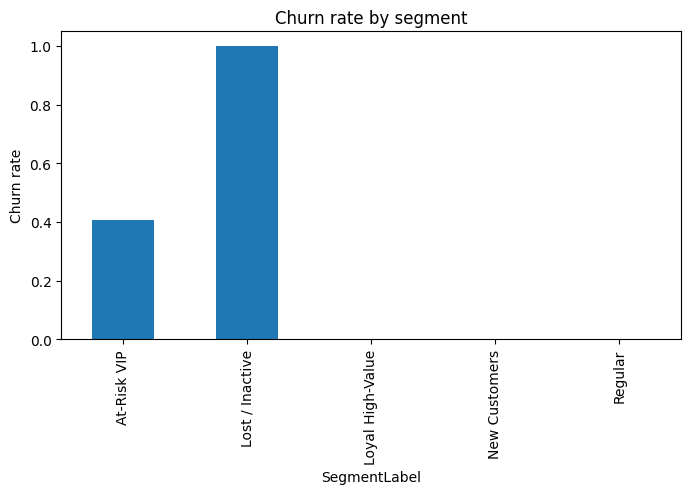

In [5]:
import matplotlib.pyplot as plt

segment_insights['ChurnRate'].plot(kind='bar', figsize=(8,4), title='Churn rate by segment')
plt.ylabel('Churn rate')
plt.show()
